In [1]:
!git clone https://github.com/srinjana-routh/SUITron.git /kaggle/working/suitron
import sys
sys.path.insert(0, '/kaggle/working/suitron')

Cloning into '/kaggle/working/suitron'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 28 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 16.06 KiB | 3.21 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [2]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 6.5 MB/s eta 0:00:00a 0:00:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 16028, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 16028 (delta 14), reused 4 (delta 4), pack-reused 16002 (from 3)
Receiving objects: 100% (16028/16028), 6.80 MiB | 19.90 MiB/s, done.
Resolving deltas: 100% (11358/11358), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match 

In [3]:
from suitron import SUITronPredictor

MODEL_PATH = '/kaggle/input/models/deeplearningsr/suitron/pytorch/version-0.0025/2/model_final.pth'

predictor = SUITronPredictor(
    model_path=MODEL_PATH,
    score_threshold=0.4,
    device='cuda'      # Kaggle gives you a T4/P100 GPU — always use this
)

[DetectionCheckpointer] Loading from /kaggle/input/models/deeplearningsr/suitron/pytorch/version-0.0025/2/model_final.pth ...
[Checkpointer] Loading from /kaggle/input/models/deeplearningsr/suitron/pytorch/version-0.0025/2/model_final.pth ...
✓ SUITronPredictor loaded
  model   : /kaggle/input/models/deeplearningsr/suitron/pytorch/version-0.0025/2/model_final.pth
  device  : cuda
  classes : ['Left', 'Right', 'Unidentifiable']
  threshold: 0.4


In [4]:
from astropy.io import fits

# .fits.fz uses tile-compressed format — decompress first
with fits.open('/kaggle/input/datasets/deeplearningsr/gong-h-alpha/H-alpha-GONG/20240928000002Bh.fits.fz') as hdul:
    hdul.info()   # run this once to see which HDU has the image data

Filename: /kaggle/input/datasets/deeplearningsr/gong-h-alpha/H-alpha-GONG/20240928000002Bh.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    148   (2048, 2048)   int16   


In [6]:
import pathlib
import suitron.io as _io
_io.pathlib = pathlib

# Patch the load_image function to recognise .fits.fz
def _patched_load_image(path, hdu_index=1):
    ext = ''.join(pathlib.Path(path).suffixes).lower()
    if ext in ('.fits', '.fit', '.fts', '.fits.fz', '.fits.gz', '.fit.fz'):
        return _io._load_fits(path, hdu_index)
    elif ext in ('.jpg', '.jpeg', '.png', '.tif', '.tiff'):
        return _io._load_standard(path)
    else:
        raise ValueError(f"Unsupported file extension '{ext}'.")

_io.load_image = _patched_load_image

# Also patch the reference inside predictor so it picks up the new function
import suitron.predictor as _pred
_pred.load_image = _patched_load_image

print("✓ Patched")

✓ Patched


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0624 09:38:57.360000 58 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='nor

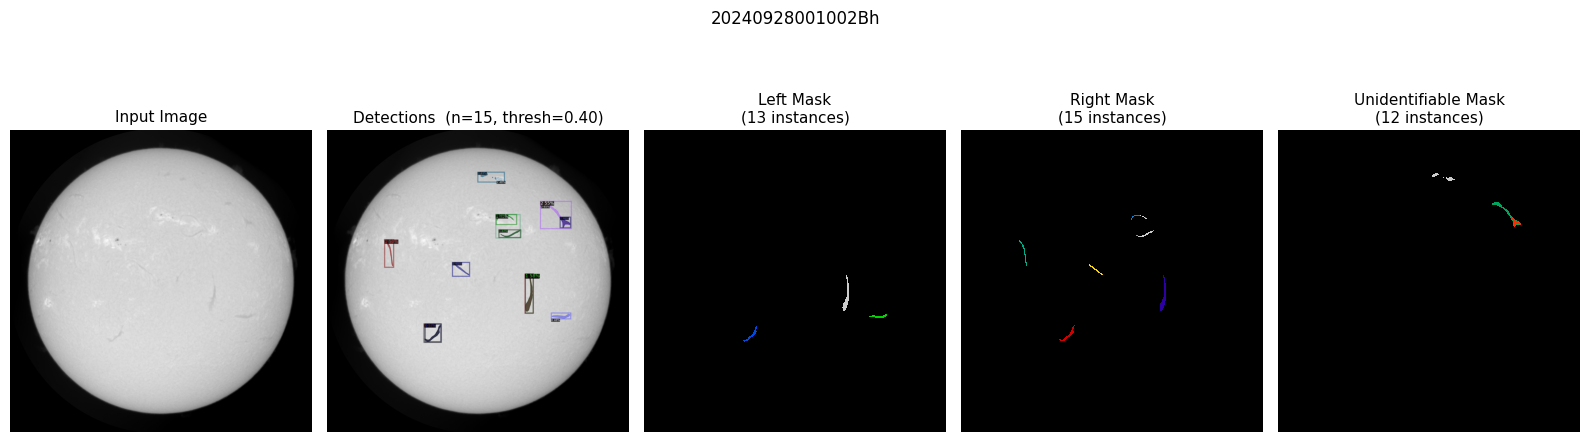

In [7]:
results = predictor.predict('/kaggle/input/datasets/deeplearningsr/gong-h-alpha/H-alpha-GONG/20240928001002Bh.fits.fz', hdu_index=1)

results.show()                              # visualise inline
# results.save('/kaggle/working/output/')     # PNG + FITS masks saved here